In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import json, re, os
from tqdm.auto import tqdm


In [21]:
# We will get a list of title from markdown links
from collections import defaultdict
import re
titles_md = defaultdict(list)


title_blocklist = ['patron', 'here', 'link', 'this', 'delete', 'this one', 'vote', 'image', 'comic explanation', 'this link', 'this thread', 'redact', '(link)', 'this post', 'CLICK THIS LINK', "here's", 'wiki']
                   

def remember_md_link_titles(markdown_text):
    # Regular expression to match markdown links
    markdown_link_pattern = re.compile(r'\[([^\]]+)\]\((http[s]?://[^\)]+)\)')

    # Find all markdown links
    for match in markdown_link_pattern.findall(markdown_text):
        title, url = match
        # tidy title of * / _ and remove leading/trailing whitespace
        title = title.strip().strip('*').strip('_')

        if len(title)<3:
            continue

        if title.startswith('http'):
            continue
        if title.startswith('^'):
            continue

        if title.lower() in title_blocklist:
            continue


        titles_md[url].append(title)



In [22]:
fs = sorted(Path('../data/json2').glob('*.json'))
len(fs)

5588

In [23]:

def extract_links_re(s:str):
    return re.findall(r'\[.*?\]\((.*?)\)', s)



from collections import defaultdict
karma = defaultdict(int) # track score
gossip = defaultdict(list) # track number and content of comments... FIXME should include subcomments?

banned_suffixes = ['jpeg', 'png', 'jpg']

data = []
for f in fs:
    s = json.loads(f.open().read())

    for comment in s['comments']:
        text = comment['body']
        links = extract_links_re(text)
        links = [l for l in links if not any(l.endswith(s) for s in banned_suffixes)]
        remember_md_link_titles(text)
        for l in links:
            karma[l] += comment['score'] / len(links)
            gossip[l].append(comment['body'])
        data += links

len(data)

25710

In [24]:
len(titles_md)

16102

In [25]:
# QC top links
pd.Series(karma).sort_values(ascending=False).head(50)

https://www.patreon.com/alexanderwales                                                                                  320.500000
https://redact.dev/home                                                                                                 201.000000
https://archiveofourown.org/works/11478249/chapters/25740126                                                            188.451984
https://www.fanfiction.net/s/10677106/1/Seventh-Horcrux                                                                 182.772817
https://docs.google.com/spreadsheets/d/1PaLrwVYgxp_SYHtkred7ybpSJPHL88lf4zB0zMKmk1E/edit?usp=sharing                    160.000000
https://redact.dev                                                                                                      150.000000
https://twigserial.wordpress.com/                                                                                       139.732955
http://topwebfiction.com/vote.php?for=a-practical-guide-to-evil                    

In [26]:
df_links = pd.Series(data).value_counts()
df_links.shape

(19424,)

In [27]:
blocklist = [
#   'reddit',
    'redact', 'pastebin', 'wikipedia', 'docs.google', 'discord','tvtropes.org', 'ask_wikibot', 'autowiki', 'banned',
    # pateron.com ?
    'reddit.com/user/', 'xkcd',

    
    ]

allowlist = ['hfy']
df_links = df_links[~df_links.index.str.contains('|'.join(blocklist), regex=True) | df_links.index.str.contains('|'.join(allowlist), regex=True)]
df_links = df_links[df_links.index.str.startswith('http')]
df_links = df_links[df_links > 1]
pd.Series(df_links.index, index=df_links.values)

54    http://topwebfiction.com/vote.php?for=a-practi...
41                 https://www.fanfiction.net/s/5193644
37    https://www.fictionpress.com/s/2961893/1/Mothe...
31    https://archiveofourown.org/works/11478249/cha...
28                    https://twigserial.wordpress.com/
                            ...                        
2     https://forums.spacebattles.com/threads/the-sa...
2     https://www.royalroad.com/fiction/54046/final-...
2     http://slatestarcodex.com/2017/06/21/against-m...
2     http://www.webtoons.com/en/romance/always-huma...
2     https://www.fanfiction.net/s/7977390/1/Life-in...
Length: 1899, dtype: object

TODO
- [ ] dedup
- [ ] convert to title

<Axes: ylabel='Frequency'>

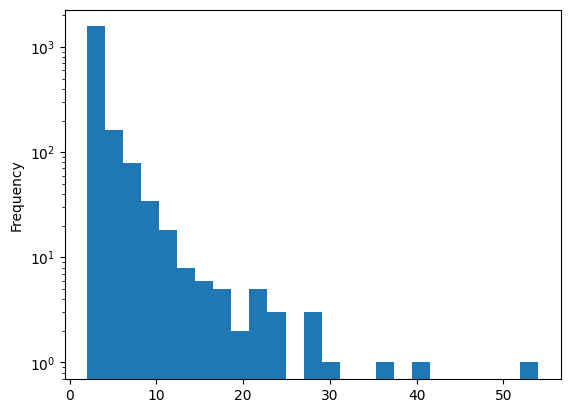

In [28]:
df_links.plot.hist(bins=25, logy=True)

In [29]:
df_links.to_markdown('../outputs/links2.md')

# Get title

This is hard as it's an adverserial web scraping problem, I'll use a mix of methods (from the markdown, requests, url)

In [ ]:
from anycache import anycache
f_cache = Path('../outputs/.anycache')

In [40]:
# import shutil
# shutil.rmtree(f_cache)

In [41]:
# dedup using title
# TODO add comments
df3 = df2.groupby('title').sum().sort_values('score', ascending=False)
df3x

from pathlib import Path
from bs4 import BeautifulSoup
import cloudscraper


f_cache = Path('../outputs/.anycache')


session = cloudscraper.create_scraper()


def get_title_md(url):
    if url in titles_md:
        s = pd.Series(titles_md[url])
        return s.value_counts().index[0] # return most common title
    return url

@anycache(f_cache)
def get_title(url):
    # first check if it's in the cache
    if url in titles_md:
        return get_title_md(url)

    # try scraping from the web
    try:
        r = session.get(url, timeout=5, allow_redirects=True)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, 'html.parser')
        title = soup.title.text.strip()
        return title
    except Exception as e:

        # if that doesn't work, does the end of the url contain a slugged title?
        # e.g. https://www.fanfiction.net/s/5193644/harry-potter-and-the-methods-of-rationality
        slugged_title = url.split('/')[-1].replace('-', ' ')
        if ' ' in slugged_title:
            return slugged_title
    
        raise e  

url = df_links.index[0]
r = get_title(url)
url, r


('http://topwebfiction.com/vote.php?for=a-practical-guide-to-evil',
 'Vote for A Practical Guide to Evil on TopWebFiction!')

In [42]:
data2 = []
for i in tqdm(range(len(df_links))):
    url = df_links.index[i]
    try:
        title = get_title(url)
    except Exception as e:
        print(f'failed to get title for {url}: {e}')
        title = ''
    comments = gossip[url]
    score = karma[url]
    num_comments = len(comments)
    data2.append(dict(url=url, title=title, score=score, comments=comments, num_comments=num_comments))

df2 = pd.DataFrame(data2)
df2

  0%|          | 0/1899 [00:00<?, ?it/s]

failed to get title for http://delphicserial.com/2017/10/21/ch01/: HTTPConnectionPool(host='delphicserial.com', port=80): Max retries exceeded with url: /2017/10/21/ch01/ (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x795f7c500040>: Failed to resolve 'delphicserial.com' ([Errno -2] Name or service not known)"))
failed to get title for https://np.reddit.com/r/youtubot/wiki/index: 404 Client Error: Not Found for url: https://np.reddit.com/r/youtubot/wiki/index
failed to get title for http://webfictionguide.com/listings/game-by-god-sludge-reformation/: 410 Client Error: Gone for url: http://webfictionguide.com/listings/game-by-god-sludge-reformation/
failed to get title for https://www.biorxiv.org/content/biorxiv/early/2016/05/26/055699.full.pdf: 'NoneType' object has no attribute 'text'
failed to get title for http://www.epubsbook.com/2015/3975.html: HTTPConnectionPool(host='www.epubsbook.com', port=80): Max retries exceeded with url: /2015/3975.html (Caus

,url,title,score,comments,num_comments
0,http://topwebfiction.com/vote.php?for=a-practi...,Vote for A Practical Guide to Evil on TopWebFi...,137.583333,[[Vote for A Practical Guide to Evil on TopWeb...,54
1,https://www.fanfiction.net/s/5193644,Time Braid,94.976914,[* [*Waves Arisen*](https://wertifloke.wordpre...,41
2,https://www.fictionpress.com/s/2961893/1/Mothe...,Mother of Learning,135.649270,[And [Mother of Learning](https://www.fictionp...,37
3,https://archiveofourown.org/works/11478249/cha...,Worth the Candle,188.451984,[>>interestingly blend ...\n\n>`[g]`enres\n\n>...,31
4,https://twigserial.wordpress.com/,Twig,139.732955,[The protagonist of [Twig](https://twigserial....,28
...,...,...,...,...,...
1894,https://forums.spacebattles.com/threads/the-sa...,The Saga of the Runt,3.333333,[Here's a few more:\n\n- [Threefold (Youjo Sen...,2
1895,https://www.royalroad.com/fiction/54046/final-...,FINAL Core,5.333333,[I really enjoy [Dungeon Without a System](htt...,2
1896,http://slatestarcodex.com/2017/06/21/against-m...,Against Murderism,1.757576,[**Here's a sneak peek of [/r/slatestarcodex](...,2
1897,http://www.webtoons.com/en/romance/always-huma...,Always Human,17.000000,[I recently finished reading the webcomic [Alw...,2


In [43]:
# QC: get top markdown titles
import itertools
l = sorted(itertools.chain(*titles_md.values()))
pd.Series(l).value_counts().head(50)

Time Braid                                                          63
Vote for A Practical Guide to Evil on TopWebFiction!                53
Mother of Learning                                                  48
Worm                                                                42
Worth the Candle                                                    41
Twig                                                                40
on the #pokengineering channel of the /r/rational Discord server    30
Handy discussion links and previous threads here                    28
Statistics                                                          27
Stop Replying                                                       27
xkcd.com                                                            27
xkcd sub                                                            27
Problems/Bugs?                                                      27
With This Ring                                                      27
Pact  

In [44]:
# join by title

def join_uniq(x:list[str]):
    return '\n'.join(set(x))

def chain_lists(x:list[list[str]]):
    return [item for sublist in x for item in sublist]

df3 = df2.groupby('title').agg({'score': 'sum', 'num_comments': 'sum', 'comments': chain_lists, 'url': join_uniq
                                }).sort_values('score', ascending=False)
df3

,score,num_comments,comments,url
title,,,,
Patreon,413.000000,17,[[Patreon](https://www.patreon.com/alexanderwa...,https://www.patreon.com/Delphic\nhttps://www.p...
Worth the Candle,360.973651,60,[>>interestingly blend ...\n\n>`[g]`enres\n\n>...,http://archiveofourown.org/works/11478249?view...
Worm,274.329267,44,[[Kitty Cat Kill Sat](https://www.royalroad.co...,https://parahumans.wordpress.com/2011/06/11/1-...
Time Braid,209.293959,65,[* [*Waves Arisen*](https://wertifloke.wordpre...,https://www.fanfiction.net/s/5193644/1/Time-Br...
Twig,198.471669,36,[The protagonist of [Twig](https://twigserial....,https://twigserial.wordpress.com/2014/12/24/ta...
...,...,...,...,...
"Chapter 10: Have You Heard, Part 2",0.249550,4,[ \nPrevious Chapters:\n\n[Chapter 1: One Smal...,https://www.fanfiction.net/s/12825305/10/The-L...
Chapter 11: Endgame,0.178122,3,[ \nPrevious Chapters:\n\n[Chapter 1: One Smal...,https://www.fanfiction.net/s/12825305/11/The-L...
"Chapter 13: Who Lives, Who Dies, Who Tells Your Story",0.170279,3,[Previous Chapters:\n\n[Chapter 1: One Small T...,https://www.fanfiction.net/s/12825305/13/The-L...


In [ ]:
df2.shape, df3.shape

((1899, 5), (1699, 4))

## Extra get a llm summary of each link

Grab all md's that mention a story, ask claude to summarize

We could also get total karma per mention

In [ ]:
import os
import dotenv
dotenv.load_dotenv()
from openai import OpenAI
client = OpenAI()

import tiktoken
enc = tiktoken.encoding_for_model("gpt-4o-mini")
cost = 0.150 / 1e6

In [97]:
def get_context(title:str):
    # from comments
    # return df3.loc[title].comments

    # or I could just all markdowns with
    fs = sorted(Path('../data/cache2').glob('*.md'))
    s = ''
    for f in fs:
        ss = f.open().read()
        if title in ss:
            i = ss.index(title)
            context = 600
            ss = ss[max(0, i-context):i+context]
            s += ss
    return s

from pydantic import BaseModel
from typing import List, Optional, Dict

class FictionInfo(BaseModel):
    name: str
    description: str
    tags: List[str]
    rating: Optional[float]
    sentiment: Optional[str]
    reviews: List[str]

f_cache = Path('../outputs/.anycache2')
@anycache(f_cache)
def get_summary(name:str, context:str):
    chat_completion = client.beta.chat.completions.parse(
        messages=[
            {"role": "system", "content": "You are Gwern Branwern, a librarian who specializes in rational fiction. You are summarising community reccomendations into a structured form."},
            {
                "role": "user",
                "content": f"""For u/gwern please summarize information about {name}. For the rating, give your own impression of the user sentiment with a rating out of 10. For the reviews tell us what users think of it and why the reccomend or disreccomend it.

### Context:

{context}"""
            }
        ],
        model="gpt-4o-mini",
        response_format=FictionInfo,
    )
    
    return chat_completion.choices[0].message.parsed.__dict__

In [ ]:
df4 = df3.copy()
df4['description'] = ''
df4['tags'] = None
df4['rating'] = None
df4['sentiment'] = None
df4['reviews'] = None


l = min(100, len(df4))
for i in tqdm(range(l)):
    url = df4.index[i]

    s = get_context(url)
    tokens = len(enc.encode(s))
    print(f"Tokens: {tokens}. Cost: {cost * tokens:.4f} USD")
    d = get_summary(url, s)
    print(url, d)

    # add the fields to the dataframe rows
    df4.loc[url, 'description'] = d['description']
    df4.loc[url, 'tags'] = ','.join(d['tags'])
    df4.loc[url, 'rating'] = d['rating']
    df4.loc[url, 'sentiment'] = d['sentiment']
    df4.loc[url, 'reviews'] = ','.join(d['reviews'])
    df4.loc[url, 'name'] = d['name']



  0%|          | 0/100 [00:00<?, ?it/s]

Tokens: 80709. Cost: 0.0121 USD
Patreon {'name': 'Patreon', 'description': 'Patreon is a membership platform that allows creators to run a subscription service. Patreon enables artists, writers, and other creators to receive funding directly from their fans or patrons, allowing for a more sustainable income while providing exclusive content in return.', 'tags': ['Subscription', 'Funding', 'Creative', 'Support', 'Community'], 'rating': 7.0, 'sentiment': 'Positive', 'reviews': ['Many users appreciate the way Patreon allows them to connect directly with their favorite creators and support them financially.', 'Patreon enables creators to share content directly and transparently with their users, which is often viewed as a refreshing change from traditional publishing.', 'Some users express frustration with Patreon’s interface and content organization, reporting difficulties in navigating and reading long-form content on the platform.', 'There are concerns about creators becoming overly rel